In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import holidays
import datetime

df_daily = pd.read_csv('./data/A - Daily.csv', index_col=0)

df_daily['Month'] = df_daily['Date'].apply(lambda x: int(x.split('/')[0]))
df_daily['Day'] = df_daily['Date'].apply(lambda x: int(x.split('/')[1]))
df_daily['Year'] = df_daily['Date'].apply(lambda x: int('20' + x.split('/')[2].split(' ')[0]))
df_daily['DayOfWeek'] = df_daily['Date'].apply(lambda x: x.split('/')[2].split(' ')[1])
df_daily.index = pd.to_datetime(list(df_daily['Date']))
df_daily = df_daily.drop(columns=['Date'])
us_holidays = holidays.US(years=[2024, 2025, 2026])
df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
df_daily['Call Volume'] = df_daily['Call Volume'].interpolate(method='linear').astype(int)
df_daily['Service Level'] = df_daily['Service Level'].interpolate(method='linear')
df_daily['Abandon Rate'] = df_daily['Abandon Rate'].interpolate(method='linear')
df_daily['CCT'] = df_daily['CCT'].interpolate(method='linear')
df_daily.head()

/tmp/ipykernel_350850/3152512362.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_daily.index = pd.to_datetime(list(df_daily['Date']))
/tmp/ipykernel_350850/3152512362.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)


,Call Volume,CCT,Service Level,Abandon Rate,Month,Day,Year,DayOfWeek,isHoliday
2024-01-01,2147,302.4500,0.9855,0.0037,1,1,2024,Mon,1
2024-01-02,7458,349.2200,0.5213,0.1136,1,2,2024,Tue,0
2024-01-03,6882,331.0700,0.7046,0.0432,1,3,2024,Wed,0
2024-01-04,6208,341.8000,0.7200,0.0403,1,4,2024,Thu,0
2024-01-05,6190,334.5600,0.8063,0.0291,1,5,2024,Fri,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# ==========================================
# 1. DATA PREPARATION (Full 2 Years)
# ==========================================

df = df_daily.copy()
# Assuming df contains: Call Volume, CCT, Service Level, Abandon Rate, Month, Day, Year, DayOfWeek, isHoliday, A
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Clean Data (Prevent NaN loss)
df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()

# Dummify Day of Week
df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=False)

# Define Targets and Features
targets = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
features = [col for col in df.columns if col not in targets]

# Reorder dataframe
df = df[targets + features]
num_targets = len(targets)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def create_sequences(data, time_steps, num_targets):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : (i + time_steps), :])
        y.append(data[i + time_steps, :num_targets])
    return np.array(X), np.array(y)

import tensorflow.keras.backend as K

def asymmetric_loss(y_true, y_pred):
    # Error = Actual - Forecast
    error = y_true - y_pred 
    
    # If error > 0 (Under-forecast): Multiply penalty by 3.0 (alpha)
    # If error < 0 (Over-forecast): Multiply penalty by 1.0 (beta)
    # You can tune the 3.0 up or down based on how brutal the autograder is!
    loss = K.maximum(3.0 * error, -1.0 * error)
    
    return K.mean(loss, axis=-1)

def build_lstm_model(input_shape, num_targets):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # Switch to 'tanh' or 'elu' for internal layers to prevent dying nodes
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(LSTM(32, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    
    # THE FIX: Force the output to stay strictly between 0 and 1 (matching the MinMaxScaler)
    model.add(Dense(num_targets, activation='sigmoid'))
    
    custom_adam = Adam(learning_rate=0.001, clipvalue=1.0)
    model.compile(optimizer=custom_adam, loss=asymmetric_loss)
    
    return model

# ==========================================
# 3. TIME-SERIES CROSS VALIDATION
# ==========================================

time_steps = 14
test_size = 60 # 60 days per test fold
n_splits = 3
fold_metrics = []

for fold in range(n_splits):
    print(f"\n{'='*40}\nStarting Fold {fold + 1} of {n_splits}\n{'='*40}")
    K.clear_session() # Clear memory
    
    # Calculate splits (Working backward from Dec 31, 2025)
    test_end = len(df) - ((n_splits - 1 - fold) * test_size)
    test_start = test_end - test_size
    
    train_df = df.iloc[:test_start]
    test_df = df.iloc[test_start:test_end]
    
    print(f"Train bounds: {train_df.index[0].date()} to {train_df.index[-1].date()}")
    print(f"Test bounds:  {test_df.index[0].date()} to {test_df.index[-1].date()}")
    print(f"Training days: {len(train_df)}")
    
    # Scale Data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_train = scaler.fit_transform(train_df)
    scaled_test = scaler.transform(test_df)
    
    # Bridge the Lookback Gap
    test_input_data = np.vstack((scaled_train[-time_steps:], scaled_test))
    
    # Create Sequences
    X_train, y_train = create_sequences(scaled_train, time_steps, num_targets)
    X_test, y_test = create_sequences(test_input_data, time_steps, num_targets)
    
    # Train Model
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), num_targets)
    model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0) 
    
    # Evaluate
    mse = model.evaluate(X_test, y_test, verbose=0)
    rmse = np.sqrt(mse)
    
    print(f"Fold {fold + 1} Scaled MSE:  {mse:.5f}")
    print(f"Fold {fold + 1} Scaled RMSE: {rmse:.5f}")
    
    fold_metrics.append(mse)

# ==========================================
# 4. FINAL RESULTS
# ==========================================
print(f"\n{'='*40}\nCross-Validation Complete\n{'='*40}")
avg_mse = np.mean(fold_metrics)
print(f"Average MSE:  {avg_mse:.5f}")
print(f"Average RMSE: {np.sqrt(avg_mse):.5f}")

/tmp/ipykernel_350850/3806654919.py:20: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()



Starting Fold 1 of 3
Train bounds: 2024-01-01 to 2025-07-04
Test bounds:  2025-07-05 to 2025-09-02
Training days: 551
Fold 1 Scaled MSE:  0.00994
Fold 1 Scaled RMSE: 0.09968

Starting Fold 2 of 3
Train bounds: 2024-01-01 to 2025-09-02
Test bounds:  2025-09-03 to 2025-11-01
Training days: 611
Fold 2 Scaled MSE:  0.01407
Fold 2 Scaled RMSE: 0.11864

Starting Fold 3 of 3
Train bounds: 2024-01-01 to 2025-11-01
Test bounds:  2025-11-02 to 2025-12-31
Training days: 671
Fold 3 Scaled MSE:  0.01771
Fold 3 Scaled RMSE: 0.13307

Cross-Validation Complete
Average MSE:  0.01391
Average RMSE: 0.11792


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. TRAIN THE FINAL PRODUCTION MODEL
# ==========================================
# Assuming 'df' is your fully prepared, dummified dataset (Jan 2024 - Dec 2025)
# Make sure targets are the first 4 columns: ['Call Volume', 'CCT', 'Service Level', 'Abandoned Rate']

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_full_data = scaler.fit_transform(df)

time_steps = 14
num_targets = 4
total_features = df.shape[1]

# Create full sequences
X_full, y_full = create_sequences(scaled_full_data, time_steps, num_targets)

# Build and train the model on 100% of the data
prod_model = build_lstm_model((X_full.shape[1], X_full.shape[2]), num_targets)
print("Training final production model...")
prod_model.fit(X_full, y_full, epochs=40, batch_size=32, verbose=1)

# ==========================================
# 2. BUILD THE FUTURE DATAFRAME (Jan-Aug 2026)
# ==========================================
future_dates = pd.date_range(start='2026-01-01', end='2026-08-31', freq='D')
future_df = pd.DataFrame(index=future_dates)

# Initialize target columns with zeros
for target in targets:
    future_df[target] = 0.0

# Add known time features
future_df['Month'] = future_df.index.month
future_df['Day'] = future_df.index.day
future_df['Year'] = future_df.index.year
future_df['DayOfWeek'] = future_df.index.day_name()
future_df['isHoliday'] = 0 # Update this manually if you know 2026 holiday dates!

# Dummify DayOfWeek
future_df = pd.get_dummies(future_df, columns=['DayOfWeek'], drop_first=False)

# Ensure columns match perfectly (adds missing days as False)
for col in df.columns:
    if col not in future_df.columns:
        if 'DW_' in col: 
            future_df[col] = False
        else:
            future_df[col] = 0.0

future_df = future_df[df.columns] # Reorder to match training data exactly

# ==========================================
# 3. THE RECURSIVE FORECAST LOOP
# ==========================================
# Grab the last 14 days of Dec 2025 to prime the model
current_window = scaled_full_data[-time_steps:]
current_window = np.expand_dims(current_window, axis=0)

print("\nStarting recursive forecast to August 2026...")

for i in range(len(future_df)):
    # Predict the next day
    pred_scaled = prod_model.predict(current_window, verbose=0)
    
    # Un-scale the prediction
    dummy_row = np.zeros((1, total_features))
    dummy_row[0, :num_targets] = pred_scaled[0]
    real_pred = scaler.inverse_transform(dummy_row)[0, :num_targets]
    
    # Save into future_df
    future_df.iloc[i, 0:num_targets] = real_pred
    
    # Create the new row combining the prediction + known future features
    new_row_real = future_df.iloc[i].values.reshape(1, -1)
    new_row_scaled = scaler.transform(new_row_real)
    
    # Slide window forward
    current_window = np.append(current_window[:, 1:, :], [new_row_scaled], axis=1)

print("Forecast complete!")

pd.options.display.float_format = '{:.4f}'.format

print("\nAugust 2026 Forecast Preview:")
print(future_df.loc['2026-08-01':'2026-08-07', targets])

Training final production model...
Epoch 1/40


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0406
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0196
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0189
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0179
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0184
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0178
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0173
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0174
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0169
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0164
Epoch 13/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0155
Epoch 14/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0147
Epoch 15/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148
Epoch 16/40
23/23 ━━━━━━━━━━

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida

Forecast complete!

August 2026 Forecast Preview:
            Call Volume      CCT  Service Level  Abandon Rate
2026-08-01    3256.4362 312.7889         0.9129        0.0145
2026-08-02    3417.8365 314.3645         0.9130        0.0144
2026-08-03    3563.2694 316.0339         0.9135        0.0140
2026-08-04    3645.5125 317.3773         0.9140        0.0136
2026-08-05    3676.5844 318.3588         0.9146        0.0133
2026-08-06    3673.5047 319.0197         0.9152        0.0130
2026-08-07    3647.8678 319.4157         0.9158        0.0129


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [14]:
import pandas as pd
import numpy as np

df_interval = pd.read_csv('./data/A - Interval.csv', index_col=0)


# 1. Define the start and end of the period
# April 1st, 2025 at 00:00 to June 30th, 2025 at 23:30
start = '2025-04-01 00:00:00'
end = '2025-06-30 23:30:00'

# 2. Generate the date range with 30-minute frequency
# 30min or 30T is the frequency for 30-minute increments
dr = pd.date_range(start=start, end=end, freq='30min')

# 3. Create the DataFrame and extract the requested columns
df = pd.DataFrame({'Timestamp': dr})

df_intervals = pd.DataFrame({
    'Month': df['Timestamp'].dt.month_name(),
    'Day': df['Timestamp'].dt.day,
    'Interval': df['Timestamp'].dt.strftime('%H:%M:%S'),
    'Day of the Week': df['Timestamp'].dt.day_name()
})

interval_df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
interval_df['Call Volume'] = interval_df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
interval_df['Service Level'] = interval_df['Service Level'].interpolate(method='polynomial', order=1)
interval_df['Abandoned Rate'] = interval_df['Abandoned Rate'].interpolate(method='linear')
interval_df['CCT'] = interval_df['CCT'].interpolate(method='polynomial', order=2)
mask = interval_df['Abandoned Calls'].isna()
interval_df.loc[mask, 'Abandoned Calls'] = (interval_df.loc[mask, 'Abandoned Rate'] * interval_df.loc[mask, 'Call Volume']).astype(int)

In [15]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CREATE THE WEIGHTED MASTER PROFILES
# ==========================================
# Assuming 'interval_df' is your April-June 2025 data
# Columns: Month, Day, Interval, Day of the Week, Service Level, Call Volume, Abandoned Rate, CCT

# A. Calculate the "Weighted Components" for each interval
# (Numerator for our weighted average: Rate * Volume)
interval_df['SL_Weight'] = interval_df['Service Level'] * interval_df['Call Volume']
interval_df['AR_Weight'] = interval_df['Abandoned Rate'] * interval_df['Call Volume']
interval_df['CCT_Weight'] = interval_df['CCT'] * interval_df['Call Volume']

# B. Roll up to find the True Daily Totals and Weighted Rates
# We group by Month and Day to isolate each specific date in the historical data
daily_actuals = interval_df.groupby(['Month', 'Day']).agg({
    'Call Volume': 'sum',
    'SL_Weight': 'sum',
    'AR_Weight': 'sum',
    'CCT_Weight': 'sum'
}).reset_index()

# C. Calculate the True Daily Weighted Average
# By dividing the sum of the weights by the total volume for the day
daily_actuals['Daily_Vol'] = daily_actuals['Call Volume']
# Using np.where to prevent division by zero just in case a day had literally 0 calls
daily_actuals['Daily_SL'] = np.where(daily_actuals['Daily_Vol'] == 0, 1.0, daily_actuals['SL_Weight'] / daily_actuals['Daily_Vol'])
daily_actuals['Daily_AR'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['AR_Weight'] / daily_actuals['Daily_Vol'])
daily_actuals['Daily_CCT'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['CCT_Weight'] / daily_actuals['Daily_Vol'])

# Drop the calculation columns, keep only the daily metrics
daily_actuals = daily_actuals[['Month', 'Day', 'Daily_Vol', 'Daily_SL', 'Daily_AR', 'Daily_CCT']]

# D. Merge back to the interval data to calculate Scaling Factors
interval_df = pd.merge(interval_df, daily_actuals, on=['Month', 'Day'])

# Volume uses a Percentage (Interval Vol / Daily Vol)
interval_df['Vol_Pct'] = np.where(interval_df['Daily_Vol'] == 0, 0, interval_df['Call Volume'] / interval_df['Daily_Vol'])

# Rates use a Scaling Factor (Interval Rate / Daily Rate)
interval_df['SL_Factor'] = np.where(interval_df['Daily_SL'] == 0, 1.0, interval_df['Service Level'] / interval_df['Daily_SL'])
interval_df['AR_Factor'] = np.where(interval_df['Daily_AR'] == 0, 1.0, interval_df['Abandoned Rate'] / interval_df['Daily_AR'])
interval_df['CCT_Factor'] = np.where(interval_df['Daily_CCT'] == 0, 1.0, interval_df['CCT'] / interval_df['Daily_CCT'])

# E. Build the MASTER PROFILE
# We average the factors across all Mondays, all Tuesdays, etc., for each specific time slot
master_profile = interval_df.groupby(['Day of the Week', 'Interval']).agg({
    'Vol_Pct': 'mean',
    'SL_Factor': 'mean',
    'AR_Factor': 'mean',
    'CCT_Factor': 'mean'
}).reset_index()

# ==========================================
# 2. APPLY TO AUGUST 2026 FORECAST
# ==========================================
# Assuming 'future_df' is your final LSTM output (Index is the Date)
future_df = future_df.reset_index()
future_df.rename(columns={'index': 'Date'}, inplace=True)
future_df['Date'] = pd.to_datetime(future_df['Date'])

# Create a master dataframe for every 30-minute block in August 2026
august_intervals = pd.date_range(start='2026-08-01 00:00:00', end='2026-08-31 23:30:00', freq='30min')
final_forecast = pd.DataFrame({'Date_Time': august_intervals})

# Extract components to match our Master Profile and LSTM predictions
final_forecast['Date'] = final_forecast['Date_Time'].dt.normalize() # Just the YYYY-MM-DD
final_forecast['Day of the Week'] = final_forecast['Date_Time'].dt.day_name()
# Format the time exactly as it appears in your snippet ('HH:MM:SS')
final_forecast['Interval'] = final_forecast['Date_Time'].dt.strftime('%H:%M:%S')

# A. Merge LSTM Daily Predictions onto the 30-min blocks
final_forecast = pd.merge(final_forecast, future_df[['Date', 'Call Volume', 'Service Level', 'Abandon Rate', 'CCT']], on='Date')

# B. Merge the Master Profiles
final_forecast = pd.merge(final_forecast, master_profile, on=['Day of the Week', 'Interval'], how='left')

# C. Calculate the Final Interval Predictions!
final_forecast['Pred_Interval_Volume'] = final_forecast['Call Volume'] * final_forecast['Vol_Pct']
final_forecast['Pred_Interval_SL'] = final_forecast['Service Level'] * final_forecast['SL_Factor']
final_forecast['Pred_Interval_AR'] = final_forecast['Abandon Rate'] * final_forecast['AR_Factor']
final_forecast['Pred_Interval_CCT'] = final_forecast['CCT'] * final_forecast['CCT_Factor']

# D. Final Safety Constraints
# Volume can't be a fraction of a call, so we round it
final_forecast['Pred_Interval_Volume'] = final_forecast['Pred_Interval_Volume'].round(0)

# Rates cannot mathematically exceed 100% or drop below 0%
final_forecast['Pred_Interval_SL'] = final_forecast['Pred_Interval_SL'].clip(lower=0.0, upper=1.0)
final_forecast['Pred_Interval_AR'] = final_forecast['Pred_Interval_AR'].clip(lower=0.0, upper=1.0)

# Clean up the dataframe for export
export_cols = ['Date_Time', 'Day of the Week', 'Interval', 'Pred_Interval_Volume', 'Pred_Interval_SL', 'Pred_Interval_AR', 'Pred_Interval_CCT']
final_forecast = final_forecast[export_cols]

final_forecast.head(10)

,Date_Time,Day of the Week,Interval,Pred_Interval_Volume,Pred_Interval_SL,Pred_Interval_AR,Pred_Interval_CCT
0,2026-08-01 00:00:00,Saturday,00:00:00,6.0000,0.9175,0.0693,373.1238
1,2026-08-01 00:30:00,Saturday,00:30:00,5.0000,0.9756,0.0000,401.5445
2,2026-08-01 01:00:00,Saturday,01:00:00,4.0000,0.9698,0.0489,361.5208
3,2026-08-01 01:30:00,Saturday,01:30:00,2.0000,0.8770,0.1273,303.6517
4,2026-08-01 02:00:00,Saturday,02:00:00,2.0000,0.9176,0.1505,473.6691
5,2026-08-01 02:30:00,Saturday,02:30:00,2.0000,1.0000,0.0000,397.3975
6,2026-08-01 03:00:00,Saturday,03:00:00,2.0000,1.0000,0.0000,441.7521
7,2026-08-01 03:30:00,Saturday,03:30:00,2.0000,1.0000,0.0000,578.3217
8,2026-08-01 04:00:00,Saturday,04:00:00,2.0000,1.0000,0.0024,454.8394
9,2026-08-01 04:30:00,Saturday,04:30:00,1.0000,1.0000,0.0168,328.9244


In [28]:
import pandas as pd
import numpy as np

def fill_template(august_intervals, template_path, output_path):
    template = pd.read_csv(template_path)
    print(f"Template loaded: {template.shape[0]} rows × {template.shape[1]} cols")

    # Helper function to guarantee both dataframes use strict 'H:MM' format 
    # Example: Converts both '00:30:00' and '0:30' into exact match '0:30'
    def to_h_mm(s):
        parts = str(s).strip().split(':')
        h = int(parts[0])
        m = int(parts[1])
        return f"{h}:{m:02d}"

    # ---------------------------------------------------------
    # 1. BUILD THE LOOKUP DICTIONARY 
    # ---------------------------------------------------------
    pred = august_intervals.copy()
    pred['Day'] = pred['Day'].astype(int)
    pred['Interval_Key'] = pred['Interval'].apply(to_h_mm)
    
    # THE FIX: Strip out any accidental memory duplicates before indexing
    pred = pred.drop_duplicates(subset=['Portfolio', 'Day', 'Interval_Key'], keep='last')
    
    # Creates a dictionary where the key is (Portfolio, Day, Interval)
    pred_dict = pred.set_index(['Portfolio', 'Day', 'Interval_Key']).to_dict(orient='index')

    # ---------------------------------------------------------
    # 2. MAP TO TEMPLATE ROWS DIRECTLY
    # ---------------------------------------------------------
    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }

    matches_found = 0
    
    for i, row in template.iterrows():
        # Clean the template keys to match the dictionary perfectly
        day = int(row['Day'])
        intv = to_h_mm(row['Interval'])
        
        for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
            lookup_key = (pf, day, intv)
            
            # If we find the exact Portfolio, Day, and Time combo: drop the data in!
            if lookup_key in pred_dict:
                data = pred_dict[lookup_key]
                template.at[i, col_cv] = data['Call_Volume']
                template.at[i, col_abd] = data['Abandoned_Calls']
                template.at[i, col_arate] = data['Abandoned_Rate']
                template.at[i, col_cct] = data['CCT']
                matches_found += 1

    print(f"✅ Data points successfully matched and mapped: {matches_found} / 5952")
    
    # ---------------------------------------------------------
    # 3. FINAL FORMATTING & EXPORT
    # ---------------------------------------------------------
    for pf, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        template[col_cv]    = template[col_cv].fillna(0).clip(lower=0).round(0).astype(int)
        template[col_abd]   = template[col_abd].fillna(0).clip(lower=0).round(0).astype(int)
        template[col_arate] = template[col_arate].fillna(0).clip(lower=0, upper=1).round(6)
        template[col_cct]   = template[col_cct].fillna(0).clip(lower=0).round(2)

    template.to_csv(output_path, index=False)
    print(f"\n✅ Saved successfully to → {output_path}")

    # Spot Check
    print("\n=== Daily CV totals (spot check) ===")
    for portfolio in 'ABCD':
        col_cv = portfolio_col_map[portfolio][0]
        daily = template.groupby('Day')[col_cv].sum()
        print(f"  Portfolio {portfolio}: mean={daily.mean():.0f}  min={daily.min():.0f}  max={daily.max():.0f}")

    return template

# Call the function (make sure this is updated!)
output_df = fill_template(
    august_intervals_final,
    template_path='./data/template_forecast_v00.csv',
    output_path='./August_2026_Forecast_v03.csv',
)

Template loaded: 1488 rows × 19 cols
✅ Data points successfully matched and mapped: 0 / 5952

✅ Saved successfully to → ./August_2026_Forecast_v03.csv

=== Daily CV totals (spot check) ===
  Portfolio A: mean=0  min=0  max=0
  Portfolio B: mean=0  min=0  max=0
  Portfolio C: mean=0  min=0  max=0
  Portfolio D: mean=0  min=0  max=0


In [21]:
import pandas as pd 
import numpy as np
import holidays
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# ==========================================
# 1. CORE PROCESSING FUNCTION
# ==========================================
def process_portfolio(portfolio):
    print(f"\n{'='*50}\n🚀 PROCESSING PORTFOLIO {portfolio}\n{'='*50}")
    
    # ----------------------------------------
    # A. DAILY DATA PREP & LSTM TRAINING
    # ----------------------------------------
    df_daily = pd.read_csv(f'./data/{portfolio} - Daily.csv', index_col=0)
    df_daily['Month'] = df_daily['Date'].apply(lambda x: int(x.split('/')[0]))
    df_daily['Day'] = df_daily['Date'].apply(lambda x: int(x.split('/')[1]))
    df_daily['Year'] = df_daily['Date'].apply(lambda x: int('20' + x.split('/')[2].split(' ')[0]))
    df_daily['DayOfWeek'] = df_daily['Date'].apply(lambda x: x.split('/')[2].split(' ')[1])
    df_daily.index = pd.to_datetime(list(df_daily['Date']))
    df_daily = df_daily.drop(columns=['Date'])
    
    us_holidays = holidays.US(years=[2024, 2025, 2026])
    df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
    df_daily['Call Volume'] = df_daily['Call Volume'].interpolate(method='linear').astype(int)
    df_daily['Service Level'] = df_daily['Service Level'].interpolate(method='linear')
    df_daily['Abandon Rate'] = df_daily['Abandon Rate'].interpolate(method='linear')
    df_daily['CCT'] = df_daily['CCT'].interpolate(method='linear')

    df = df_daily.copy()
    df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()
    df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=False)

    targets = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
    features = [col for col in df.columns if col not in targets]
    df = df[targets + features]
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_full_data = scaler.fit_transform(df)

    time_steps = 14
    num_targets = 4
    total_features = df.shape[1]

    def create_sequences(data, time_steps, num_targets):
        X, y = [], []
        for i in range(len(data) - time_steps):
            X.append(data[i : (i + time_steps), :])
            y.append(data[i + time_steps, :num_targets])
        return np.array(X), np.array(y)

    X_full, y_full = create_sequences(scaled_full_data, time_steps, num_targets)

    K.clear_session()
    model = Sequential()
    model.add(Input(shape=(X_full.shape[1], X_full.shape[2])))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(num_targets, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), loss='mean_squared_error')
    
    print("Training LSTM (40 epochs)...")
    model.fit(X_full, y_full, epochs=40, batch_size=32, verbose=0)

    # ----------------------------------------
    # B. RECURSIVE FORECAST (August 2026)
    # ----------------------------------------
    future_dates = pd.date_range(start='2026-08-01', end='2026-08-31', freq='D')
    future_df = pd.DataFrame(index=future_dates)
    for target in targets: future_df[target] = 0.0
    
    future_df['Month'] = future_df.index.month
    future_df['Day'] = future_df.index.day
    future_df['Year'] = future_df.index.year
    future_df['DayOfWeek'] = future_df.index.day_name()
    future_df['isHoliday'] = 0 
    future_df = pd.get_dummies(future_df, columns=['DayOfWeek'], drop_first=False)
    
    for col in df.columns:
        if col not in future_df.columns:
            future_df[col] = False if 'DW_' in col else 0.0
    future_df = future_df[df.columns]

    current_window = scaled_full_data[-time_steps:]
    current_window = np.expand_dims(current_window, axis=0)

    for i in range(len(future_df)):
        pred_scaled = model.predict(current_window, verbose=0)
        dummy_row = np.zeros((1, total_features))
        dummy_row[0, :num_targets] = pred_scaled[0]
        real_pred = scaler.inverse_transform(dummy_row)[0, :num_targets]
        future_df.iloc[i, 0:num_targets] = real_pred
        new_row_real = future_df.iloc[i].values.reshape(1, -1)
        new_row_scaled = scaler.transform(new_row_real)
        current_window = np.append(current_window[:, 1:, :], [new_row_scaled], axis=1)

    future_df = future_df.reset_index().rename(columns={'index': 'Date'})
    future_df['Date'] = pd.to_datetime(future_df['Date'])

    # ----------------------------------------
    # C. INTERVAL PROFILING & DISAGGREGATION
    # ----------------------------------------
    df_interval = pd.read_csv(f'./data/{portfolio} - Interval.csv', index_col=0)
    
    # Map your generated April-June dates to the raw interval data
    dr = pd.date_range(start='2025-04-01 00:00:00', end='2025-06-30 23:30:00', freq='30min')
    df_timestamps = pd.DataFrame({'Timestamp': dr})
    df_intervals = pd.DataFrame({
        'Month': df_timestamps['Timestamp'].dt.month_name(),
        'Day': df_timestamps['Timestamp'].dt.day,
        'Interval': df_timestamps['Timestamp'].dt.strftime('%H:%M:%S'),
        'Day of the Week': df_timestamps['Timestamp'].dt.day_name()
    })

    interval_df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
    interval_df['Call Volume'] = interval_df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
    interval_df['Service Level'] = interval_df['Service Level'].interpolate(method='polynomial', order=1)
    interval_df['Abandoned Rate'] = interval_df['Abandoned Rate'].interpolate(method='linear')
    interval_df['CCT'] = interval_df['CCT'].interpolate(method='polynomial', order=2)

    # Master Profile Weights
    interval_df['SL_Weight'] = interval_df['Service Level'] * interval_df['Call Volume']
    interval_df['AR_Weight'] = interval_df['Abandoned Rate'] * interval_df['Call Volume']
    interval_df['CCT_Weight'] = interval_df['CCT'] * interval_df['Call Volume']

    daily_actuals = interval_df.groupby(['Month', 'Day']).agg({
        'Call Volume': 'sum', 'SL_Weight': 'sum', 'AR_Weight': 'sum', 'CCT_Weight': 'sum'
    }).reset_index()

    daily_actuals['Daily_Vol'] = daily_actuals['Call Volume']
    daily_actuals['Daily_SL'] = np.where(daily_actuals['Daily_Vol'] == 0, 1.0, daily_actuals['SL_Weight'] / daily_actuals['Daily_Vol'])
    daily_actuals['Daily_AR'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['AR_Weight'] / daily_actuals['Daily_Vol'])
    daily_actuals['Daily_CCT'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['CCT_Weight'] / daily_actuals['Daily_Vol'])

    daily_actuals = daily_actuals[['Month', 'Day', 'Daily_Vol', 'Daily_SL', 'Daily_AR', 'Daily_CCT']]
    interval_df = pd.merge(interval_df, daily_actuals, on=['Month', 'Day'])

    interval_df['Vol_Pct'] = np.where(interval_df['Daily_Vol'] == 0, 0, interval_df['Call Volume'] / interval_df['Daily_Vol'])
    interval_df['SL_Factor'] = np.where(interval_df['Daily_SL'] == 0, 1.0, interval_df['Service Level'] / interval_df['Daily_SL'])
    interval_df['AR_Factor'] = np.where(interval_df['Daily_AR'] == 0, 1.0, interval_df['Abandoned Rate'] / interval_df['Daily_AR'])
    interval_df['CCT_Factor'] = np.where(interval_df['Daily_CCT'] == 0, 1.0, interval_df['CCT'] / interval_df['Daily_CCT'])

    master_profile = interval_df.groupby(['Day of the Week', 'Interval']).agg({
        'Vol_Pct': 'mean', 'SL_Factor': 'mean', 'AR_Factor': 'mean', 'CCT_Factor': 'mean'
    }).reset_index()

    # Apply to August 2026
    august_intervals = pd.date_range(start='2026-08-01 00:00:00', end='2026-08-31 23:30:00', freq='30min')
    final_forecast = pd.DataFrame({'Date_Time': august_intervals})
    final_forecast['Date'] = final_forecast['Date_Time'].dt.normalize()
    final_forecast['Day of the Week'] = final_forecast['Date_Time'].dt.day_name()
    final_forecast['Interval'] = final_forecast['Date_Time'].dt.strftime('%H:%M:%S')

    final_forecast = pd.merge(final_forecast, future_df[['Date', 'Call Volume', 'Service Level', 'Abandon Rate', 'CCT']], on='Date')
    final_forecast = pd.merge(final_forecast, master_profile, on=['Day of the Week', 'Interval'], how='left')

    # ----------------------------------------
    # D. FORMAT FOR EXPORT TEMPLATE
    # ----------------------------------------
    res = pd.DataFrame()
    res['Portfolio'] = portfolio
    res['Date'] = final_forecast['Date_Time'].dt.date
    res['Month'] = 'August'
    res['Day'] = final_forecast['Date_Time'].dt.day
    res['DayOfWeek'] = final_forecast['Day of the Week']
    res['DayOfWeek_N'] = final_forecast['Date_Time'].dt.dayofweek
    res['Interval'] = final_forecast['Interval']
    res['IntervalIdx'] = final_forecast['Date_Time'].dt.hour * 2 + final_forecast['Date_Time'].dt.minute // 30
    
    # Calculate final metrics with safety constraints
    res['Call_Volume'] = (final_forecast['Call Volume'] * final_forecast['Vol_Pct']).round(0).astype(int)
    res['CCT'] = final_forecast['CCT'] * final_forecast['CCT_Factor']
    res['Abandoned_Rate'] = (final_forecast['Abandon Rate'] * final_forecast['AR_Factor']).clip(lower=0.0, upper=1.0)
    
    # Calculate Abandoned Calls directly from Volume and Rate
    res['Abandoned_Calls'] = (res['Call_Volume'] * res['Abandoned_Rate']).round(0).astype(int)
    
    return res

# ==========================================
# 2. EXECUTE LOOP & CONCATENATE
# ==========================================
portfolios = ['A', 'B', 'C', 'D']
all_forecasts = []

for pf in portfolios:
    # Ensure you have 'B - Daily.csv', 'B - Interval.csv', etc. in your ./data folder!
    df_pf = process_portfolio(pf)
    all_forecasts.append(df_pf)

# Stack them vertically into one massive dataframe
august_intervals_final = pd.concat(all_forecasts, ignore_index=True)

print(f"\n✅ All portfolios processed! Final Shape: {august_intervals_final.shape}")

# ==========================================
# 3. EXPORT TO TEMPLATE
# ==========================================
# Use your provided export function
output_df = fill_template(
    august_intervals_final,
    template_path='./data/template_forecast_v00.csv',
    output_path='./August_2026_Forecast_v01.csv',
)


🚀 PROCESSING PORTFOLIO A


/tmp/ipykernel_350850/1840569179.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_daily.index = pd.to_datetime(list(df_daily['Date']))
/tmp/ipykernel_350850/1840569179.py:28: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
/tmp/ipykernel_350850/1840569179.py:35: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()


Training LSTM (40 epochs)...


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida


🚀 PROCESSING PORTFOLIO B


...


🚀 PROCESSING PORTFOLIO D


/tmp/ipykernel_350850/1840569179.py:28: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
/tmp/ipykernel_350850/1840569179.py:35: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()


Training LSTM (40 epochs)...


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida


✅ All portfolios processed! Final Shape: (5952, 12)
Template loaded: 1488 rows × 19 cols

✅  Filled template saved → ./August_2026_Forecast_v01.csv
   Rows: 1488  |  Expected: 1488 = 1488

   ⚠️  Null cells found:
Calls_Offered_A      1488
Abandoned_Calls_A    1488
Abandoned_Rate_A     1488
CCT_A                1488
Calls_Offered_B      1488
Abandoned_Calls_B    1488
Abandoned_Rate_B     1488
CCT_B                1488
Calls_Offered_C      1488
Abandoned_Calls_C    1488
Abandoned_Rate_C     1488
CCT_C                1488
Calls_Offered_D      1488
Abandoned_Calls_D    1488
Abandoned_Rate_D     1488
CCT_D                1488
dtype: int64
   ✅  No negative values.

=== Daily CV totals (spot check) ===
  Portfolio A: mean=0  min=0  max=0
  Portfolio B: mean=0  min=0  max=0
  Portfolio C: mean=0  min=0  max=0
  Portfolio D: mean=0  min=0  max=0


In [30]:
import pandas as pd 
import numpy as np
import holidays
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# ==========================================
# OPTIMIZATION 1: ASYMMETRIC LOSS FUNCTION
# ==========================================
def asymmetric_loss(y_true, y_pred):
    """
    Penalizes under-forecasting (Actual > Forecast) 3 times as heavily 
    as over-forecasting, perfectly aligning with the Workload Penalty rules.
    """
    error = y_true - y_pred 
    loss = K.maximum(3.0 * error, -1.0 * error)
    return K.mean(loss, axis=-1)

# ==========================================
# 1. CORE PROCESSING FUNCTION
# ==========================================
def process_portfolio(portfolio):
    print(f"\n{'='*50}\n🚀 PROCESSING PORTFOLIO {portfolio}\n{'='*50}")
    
    # ----------------------------------------
    # A. DAILY DATA PREP & LSTM TRAINING
    # ----------------------------------------
    df_daily = pd.read_csv(f'./data/{portfolio} - Daily.csv', index_col=0)
    df_daily['Month'] = df_daily['Date'].apply(lambda x: int(x.split('/')[0]))
    df_daily['Day'] = df_daily['Date'].apply(lambda x: int(x.split('/')[1]))
    df_daily['Year'] = df_daily['Date'].apply(lambda x: int('20' + x.split('/')[2].split(' ')[0]))
    df_daily['DayOfWeek'] = df_daily['Date'].apply(lambda x: x.split('/')[2].split(' ')[1])
    df_daily.index = pd.to_datetime(list(df_daily['Date']))
    df_daily = df_daily.drop(columns=['Date'])
    
    us_holidays = holidays.US(years=[2024, 2025, 2026])
    df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
    df_daily['Call Volume'] = df_daily['Call Volume'].interpolate(method='linear').astype(int)
    df_daily['Service Level'] = df_daily['Service Level'].interpolate(method='linear')
    df_daily['Abandon Rate'] = df_daily['Abandon Rate'].interpolate(method='linear')
    df_daily['CCT'] = df_daily['CCT'].interpolate(method='linear')

    # OPTIMIZATION 2A: Explicit Workload Feature
    df_daily['Workload'] = df_daily['Call Volume'] * df_daily['CCT']

    df = df_daily.copy()
    df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()
    df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=False)

    targets = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
    features = [col for col in df.columns if col not in targets]
    df = df[targets + features]
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_full_data = scaler.fit_transform(df)

    time_steps = 14
    num_targets = 4
    total_features = df.shape[1]

    def create_sequences(data, time_steps, num_targets):
        X, y = [], []
        for i in range(len(data) - time_steps):
            X.append(data[i : (i + time_steps), :])
            y.append(data[i + time_steps, :num_targets])
        return np.array(X), np.array(y)

    X_full, y_full = create_sequences(scaled_full_data, time_steps, num_targets)

    K.clear_session()
    model = Sequential()
    model.add(Input(shape=(X_full.shape[1], X_full.shape[2])))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(num_targets, activation='sigmoid'))
    
    # Compile with the Asymmetric Loss Function
    model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), loss=asymmetric_loss)
    
    print("Training LSTM (40 epochs) with Asymmetric Loss...")
    model.fit(X_full, y_full, epochs=40, batch_size=32, verbose=0)

    # ----------------------------------------
    # B. RECURSIVE FORECAST (August 2026)
    # ----------------------------------------
    future_dates = pd.date_range(start='2026-08-01', end='2026-08-31', freq='D')
    future_df = pd.DataFrame(index=future_dates)
    for target in targets: future_df[target] = 0.0
    
    future_df['Month'] = future_df.index.month
    future_df['Day'] = future_df.index.day
    future_df['Year'] = future_df.index.year
    future_df['DayOfWeek'] = future_df.index.day_name()
    future_df['isHoliday'] = 0 
    future_df = pd.get_dummies(future_df, columns=['DayOfWeek'], drop_first=False)
    
    for col in df.columns:
        if col not in future_df.columns:
            future_df[col] = False if 'DW_' in col else 0.0
    future_df = future_df[df.columns] # Enforces exact column order

    current_window = scaled_full_data[-time_steps:]
    current_window = np.expand_dims(current_window, axis=0)

    for i in range(len(future_df)):
        pred_scaled = model.predict(current_window, verbose=0)
        dummy_row = np.zeros((1, total_features))
        dummy_row[0, :num_targets] = pred_scaled[0]
        real_pred = scaler.inverse_transform(dummy_row)[0, :num_targets]
        
        # Save the 4 targets
        future_df.iloc[i, 0:num_targets] = real_pred
        
        # OPTIMIZATION 2B: Dynamically calculate Workload for the new row 
        # so the LSTM has it as an accurate feature for tomorrow's prediction
        wl_idx = future_df.columns.get_loc('Workload')
        future_df.iloc[i, wl_idx] = real_pred[0] * real_pred[1] # Volume * CCT
        
        new_row_real = future_df.iloc[i].values.reshape(1, -1)
        new_row_scaled = scaler.transform(new_row_real)
        current_window = np.append(current_window[:, 1:, :], [new_row_scaled], axis=1)

    future_df = future_df.reset_index().rename(columns={'index': 'Date'})
    future_df['Date'] = pd.to_datetime(future_df['Date'])

    # ----------------------------------------
    # C. INTERVAL PROFILING & DISAGGREGATION
    # ----------------------------------------
    df_interval = pd.read_csv(f'./data/{portfolio} - Interval.csv', index_col=0)
    
    dr = pd.date_range(start='2025-04-01 00:00:00', end='2025-06-30 23:30:00', freq='30min')
    df_timestamps = pd.DataFrame({'Timestamp': dr})
    df_intervals = pd.DataFrame({
        'Month': df_timestamps['Timestamp'].dt.month_name(),
        'Day': df_timestamps['Timestamp'].dt.day,
        'Interval': df_timestamps['Timestamp'].dt.strftime('%H:%M:%S'),
        'Day of the Week': df_timestamps['Timestamp'].dt.day_name()
    })

    interval_df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
    interval_df['Call Volume'] = interval_df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
    interval_df['Service Level'] = interval_df['Service Level'].interpolate(method='polynomial', order=1)
    interval_df['Abandoned Rate'] = interval_df['Abandoned Rate'].interpolate(method='linear')
    interval_df['CCT'] = interval_df['CCT'].interpolate(method='polynomial', order=2)

    interval_df['SL_Weight'] = interval_df['Service Level'] * interval_df['Call Volume']
    interval_df['AR_Weight'] = interval_df['Abandoned Rate'] * interval_df['Call Volume']
    interval_df['CCT_Weight'] = interval_df['CCT'] * interval_df['Call Volume']

    daily_actuals = interval_df.groupby(['Month', 'Day']).agg({
        'Call Volume': 'sum', 'SL_Weight': 'sum', 'AR_Weight': 'sum', 'CCT_Weight': 'sum'
    }).reset_index()

    daily_actuals['Daily_Vol'] = daily_actuals['Call Volume']
    daily_actuals['Daily_SL'] = np.where(daily_actuals['Daily_Vol'] == 0, 1.0, daily_actuals['SL_Weight'] / daily_actuals['Daily_Vol'])
    daily_actuals['Daily_AR'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['AR_Weight'] / daily_actuals['Daily_Vol'])
    daily_actuals['Daily_CCT'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['CCT_Weight'] / daily_actuals['Daily_Vol'])

    daily_actuals = daily_actuals[['Month', 'Day', 'Daily_Vol', 'Daily_SL', 'Daily_AR', 'Daily_CCT']]
    interval_df = pd.merge(interval_df, daily_actuals, on=['Month', 'Day'])

    interval_df['Vol_Pct'] = np.where(interval_df['Daily_Vol'] == 0, 0, interval_df['Call Volume'] / interval_df['Daily_Vol'])
    interval_df['SL_Factor'] = np.where(interval_df['Daily_SL'] == 0, 1.0, interval_df['Service Level'] / interval_df['Daily_SL'])
    interval_df['AR_Factor'] = np.where(interval_df['Daily_AR'] == 0, 1.0, interval_df['Abandoned Rate'] / interval_df['Daily_AR'])
    interval_df['CCT_Factor'] = np.where(interval_df['Daily_CCT'] == 0, 1.0, interval_df['CCT'] / interval_df['Daily_CCT'])

    master_profile = interval_df.groupby(['Day of the Week', 'Interval']).agg({
        'Vol_Pct': 'mean', 'SL_Factor': 'mean', 'AR_Factor': 'mean', 'CCT_Factor': 'mean'
    }).reset_index()

    august_intervals = pd.date_range(start='2026-08-01 00:00:00', end='2026-08-31 23:30:00', freq='30min')
    final_forecast = pd.DataFrame({'Date_Time': august_intervals})
    final_forecast['Date'] = final_forecast['Date_Time'].dt.normalize()
    final_forecast['Day of the Week'] = final_forecast['Date_Time'].dt.day_name()
    final_forecast['Interval'] = final_forecast['Date_Time'].dt.strftime('%H:%M:%S')

    final_forecast = pd.merge(final_forecast, future_df[['Date', 'Call Volume', 'Service Level', 'Abandon Rate', 'CCT']], on='Date')
    final_forecast = pd.merge(final_forecast, master_profile, on=['Day of the Week', 'Interval'], how='left')

    # ----------------------------------------
    # D. FORMAT FOR EXPORT TEMPLATE
    # ----------------------------------------
    res = pd.DataFrame()
    
    # THE FIX: Assign a column with actual length FIRST.
    res['Date'] = final_forecast['Date_Time'].dt.date
    
    # Now that the dataframe has 1,488 rows, these scalar assignments work perfectly!
    res['Portfolio'] = portfolio
    res['Month'] = 'August'
    
    # Continue mapping the rest of the columns
    res['Day'] = final_forecast['Date_Time'].dt.day
    res['DayOfWeek'] = final_forecast['Day of the Week']
    res['DayOfWeek_N'] = final_forecast['Date_Time'].dt.dayofweek
    res['Interval'] = final_forecast['Interval']
    res['IntervalIdx'] = final_forecast['Date_Time'].dt.hour * 2 + final_forecast['Date_Time'].dt.minute // 30
    
    # OPTIMIZATION 3: Post-Processing Multipliers (3% Buffer)
    res['Call_Volume'] = (final_forecast['Call Volume'] * final_forecast['Vol_Pct'] * 1.03).round(0).astype(int)
    res['CCT'] = (final_forecast['CCT'] * final_forecast['CCT_Factor'] * 1.03).round(2)
    
    res['Abandoned_Rate'] = (final_forecast['Abandon Rate'] * final_forecast['AR_Factor']).clip(lower=0.0, upper=1.0)
    res['Abandoned_Calls'] = (res['Call_Volume'] * res['Abandoned_Rate']).round(0).astype(int)
    
    return res

# ==========================================
# 2. EXECUTE LOOP & CONCATENATE
# ==========================================
portfolios = ['A', 'B', 'C', 'D']
all_forecasts = []

for pf in portfolios:
    df_pf = process_portfolio(pf)
    all_forecasts.append(df_pf)

august_intervals_final = pd.concat(all_forecasts, ignore_index=True)
print(f"\n✅ All portfolios processed! Final Shape: {august_intervals_final.shape}")

# ==========================================
# 3. EXPORT TO TEMPLATE
# ==========================================
output_df = fill_template(
    august_intervals_final,
    template_path='./data/template_forecast_v00.csv',
    output_path='./August_2026_Forecast_v02.csv',
)


🚀 PROCESSING PORTFOLIO A


/tmp/ipykernel_350850/3934910520.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_daily.index = pd.to_datetime(list(df_daily['Date']))
/tmp/ipykernel_350850/3934910520.py:40: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
/tmp/ipykernel_350850/3934910520.py:50: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()


Training LSTM (40 epochs) with Asymmetric Loss...


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida


🚀 PROCESSING PORTFOLIO B


...


🚀 PROCESSING PORTFOLIO D


/tmp/ipykernel_350850/3934910520.py:40: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
/tmp/ipykernel_350850/3934910520.py:50: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()


Training LSTM (40 epochs) with Asymmetric Loss...


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida


✅ All portfolios processed! Final Shape: (5952, 12)
Template loaded: 1488 rows × 19 cols
✅ Data points successfully matched and mapped: 5952 / 5952

✅ Saved successfully to → ./August_2026_Forecast_v02.csv

=== Daily CV totals (spot check) ===
  Portfolio A: mean=4354  min=1807  max=5303
  Portfolio B: mean=9593  min=6082  max=11936
  Portfolio C: mean=16184  min=9695  max=23227
  Portfolio D: mean=10617  min=5959  max=13624


In [33]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

# Suppress harmless statsmodels warnings for cleaner output
warnings.filterwarnings('ignore', '.*ValueWarning.*')

# ==========================================
# 1. TEMPLATE FILLER FUNCTION
# ==========================================
def fill_template(august_intervals: pd.DataFrame,
                  template_path: str = './data/template_forecast_v00.csv',
                  output_path:   str = './August_2026_Forecast_FINAL.csv') -> pd.DataFrame:
    
    template = pd.read_csv(template_path)
    print(f"Template loaded: {template.shape[0]} rows × {template.shape[1]} cols")
 
    def normalise_interval(s: str) -> str:
        if pd.isna(s) or str(s).strip().lower() == 'nan': return np.nan
        parts = str(s).strip().split(':')
        if len(parts) != 2: return np.nan
        return f"{int(parts[0])}:{int(parts[1]):02d}"
 
    template['_interval_key'] = template['Interval'].apply(normalise_interval)
    pred = august_intervals.copy()
    pred['_interval_key'] = pred['Interval'].apply(normalise_interval)
 
    if pred['Abandoned_Rate'].max() > 1.5:
        pred['Abandoned_Rate'] = pred['Abandoned_Rate'] / 100
        
    filled = template.copy()
    portfolio_col_map = {
        'A': ('Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A'),
        'B': ('Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B'),
        'C': ('Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C'),
        'D': ('Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D'),
    }
 
    for portfolio, (col_cv, col_abd, col_arate, col_cct) in portfolio_col_map.items():
        pf_pred = pred[pred['Portfolio'] == portfolio][
            ['Day', '_interval_key', 'Call_Volume', 'Abandoned_Calls', 'Abandoned_Rate', 'CCT']
        ].copy()
 
        pf_pred = pf_pred.rename(columns={
            'Call_Volume':     col_cv,
            'Abandoned_Calls': col_abd,
            'Abandoned_Rate':  col_arate,
            'CCT':             col_cct,
        })
 
        filled = filled.drop(columns=[col_cv, col_abd, col_arate, col_cct], errors='ignore')
        filled = filled.merge(pf_pred, on=['Day', '_interval_key'], how='left')
 
    for portfolio in 'ABCD':
        col_cv, col_abd, col_arate, col_cct = portfolio_col_map[portfolio]
        
        filled[col_cv]    = filled[col_cv].fillna(0).clip(lower=0).round(0).astype('Int64')
        filled[col_abd]   = filled[col_abd].fillna(0).clip(lower=0).round(0).astype('Int64')
        filled[col_arate] = filled[col_arate].interpolate(method='linear').fillna(0).clip(lower=0, upper=1).round(6)
        filled[col_cct]   = filled[col_cct].interpolate(method='linear').fillna(0).clip(lower=0).round(2)
 
    out_cols = list(template.columns)
    filled = filled[out_cols]
    filled.to_csv(output_path, index=False)
    
    print(f"\n✅  Filled template saved → {output_path}")
    return filled

# ==========================================
# 2. MODELING & PROFILING LOGIC
# ==========================================
def normalise_interval(s) -> str:
    """Ensures consistent interval formatting (e.g. '0:30', '13:00')"""
    if pd.isna(s) or str(s).strip().lower() == 'nan':
        return np.nan
    parts = str(s).strip().split(':')
    if len(parts) != 2:
        return np.nan
    return f"{int(parts[0])}:{int(parts[1]):02d}"

def generate_firm_forecast(firm: str, data_dir: str = './data/') -> pd.DataFrame:
    print(f"\n--- Processing Firm {firm} ---")
    
    daily_path = os.path.join(data_dir, f'{firm} - Daily.csv')
    interval_path = os.path.join(data_dir, f'{firm} - Interval.csv')
    
    daily_df = pd.read_csv(daily_path, encoding='utf-8-sig')
    interval_df = pd.read_csv(interval_path, encoding='utf-8-sig')
    
    daily_df.columns = daily_df.columns.str.strip().str.replace(' ', '_')
    interval_df.columns = interval_df.columns.str.strip().str.replace(' ', '_')

    if 'Month' in interval_df.columns and 'Day' in interval_df.columns:
        date_strings = interval_df['Month'].astype(str) + " " + interval_df['Day'].astype(str) + " 2025"
        interval_df['Date'] = pd.to_datetime(date_strings, format='mixed')
    
    daily_df['Date'] = pd.to_datetime(daily_df['Date'], format='mixed')
    
    # ---------------------------------------------------------
    # DAILY PREPROCESSING
    # ---------------------------------------------------------
    daily_df = daily_df.set_index('Date').sort_index()
    daily_df = daily_df.resample('D').mean() 
    daily_df['Call_Volume'] = daily_df['Call_Volume'].interpolate(method='linear').ffill().bfill()
    
    historical_volume = daily_df['Call_Volume'].values
    
    model = ExponentialSmoothing(
        historical_volume, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=7, 
        initialization_method="estimated"
    ).fit()
    
    august_dates = pd.date_range(start='2026-08-01', end='2026-08-31', freq='D')
    daily_forecast = pd.DataFrame({
        'Date': august_dates,
        'Forecast_Volume': model.forecast(31),
        'Day': august_dates.day,
        'DayOfWeek': august_dates.dayofweek
    })
    
    # ---------------------------------------------------------
    # INTERVAL PREPROCESSING (Vectorized & Bug-Free)
    # ---------------------------------------------------------
    interval_df['DayOfWeek'] = interval_df['Date'].dt.dayofweek
    
    interval_df = interval_df.dropna(subset=['Interval'])
    interval_df['Interval'] = interval_df['Interval'].apply(normalise_interval)
    interval_df = interval_df.dropna(subset=['Interval'])
    
    daily_totals = interval_df.groupby('Date')['Call_Volume'].sum().reset_index(name='Daily_Total_Volume')
    interval_df = interval_df.merge(daily_totals, on='Date')
    
    interval_df['Volume_Weight'] = interval_df['Call_Volume'] / interval_df['Daily_Total_Volume']
    interval_df['Volume_Weight'] = interval_df['Volume_Weight'].fillna(0)

    # Calculate weighted numerators mathematically to avoid .apply() index bugs
    interval_df['CCT_Vol'] = interval_df['CCT'] * interval_df['Call_Volume']
    interval_df['Aband_Vol'] = interval_df['Abandoned_Rate'] * interval_df['Call_Volume']
    
    # Get standard averages (useful for fallback if volume is 0)
    means = interval_df.groupby(['DayOfWeek', 'Interval'])[['Volume_Weight', 'CCT', 'Abandoned_Rate']].mean().reset_index()
    
    # Get sums (for the weighted calculations)
    sums = interval_df.groupby(['DayOfWeek', 'Interval'])[['Call_Volume', 'CCT_Vol', 'Aband_Vol']].sum().reset_index()
    
    # Build our profiles dataframe
    profiles = means[['DayOfWeek', 'Interval', 'Volume_Weight']].copy()
    
    # Vectorized weighted averages
    profiles['Profile_CCT'] = np.where(
        sums['Call_Volume'] > 0, 
        sums['CCT_Vol'] / sums['Call_Volume'], 
        means['CCT']
    )
    
    profiles['Profile_Abandoned_Rate'] = np.where(
        sums['Call_Volume'] > 0, 
        sums['Aband_Vol'] / sums['Call_Volume'], 
        means['Abandoned_Rate']
    )
    
    # Generate perfect 7x48 Grid to prevent missing rows
    all_dows = list(range(7))
    all_ints = [f"{h}:{m:02d}" for h in range(24) for m in (0, 30)]
    grid = pd.MultiIndex.from_product([all_dows, all_ints], names=['DayOfWeek', 'Interval']).to_frame(index=False)
    
    # Merge existing profiles into perfect grid
    profiles = grid.merge(profiles, on=['DayOfWeek', 'Interval'], how='left')
    
    profiles['Volume_Weight'] = profiles['Volume_Weight'].fillna(0)
    profiles['Profile_CCT'] = profiles['Profile_CCT'].interpolate(method='linear').ffill().bfill()
    profiles['Profile_Abandoned_Rate'] = profiles['Profile_Abandoned_Rate'].interpolate(method='linear').ffill().bfill()
    
    profiles['Volume_Weight'] = profiles['Volume_Weight'] / profiles.groupby('DayOfWeek')['Volume_Weight'].transform('sum')
    profiles['Volume_Weight'] = profiles['Volume_Weight'].fillna(0) 

    # 4. Merge Forecast with Profiles
    august_intervals = daily_forecast.merge(profiles, on='DayOfWeek', how='left')
    
    august_intervals['Call_Volume'] = august_intervals['Forecast_Volume'] * august_intervals['Volume_Weight']
    august_intervals['Abandoned_Rate'] = august_intervals['Profile_Abandoned_Rate']
    august_intervals['CCT'] = august_intervals['Profile_CCT']
    august_intervals['Abandoned_Calls'] = august_intervals['Call_Volume'] * august_intervals['Abandoned_Rate']
    august_intervals['Portfolio'] = firm
    
    final_cols = ['Portfolio', 'Day', 'Interval', 'Call_Volume', 'Abandoned_Calls', 'Abandoned_Rate', 'CCT']
    return august_intervals[final_cols]

# ==========================================
# 3. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    FIRMS = ['A', 'B', 'C', 'D']
    all_firms_forecasts = []
    
    try:
        for firm in FIRMS:
            firm_df = generate_firm_forecast(firm, data_dir='./data/')
            all_firms_forecasts.append(firm_df)
            
        final_august_intervals = pd.concat(all_firms_forecasts, ignore_index=True)
        print(f"\nAll firms processed. Combined rows: {len(final_august_intervals)}")
        
        fill_template(
            august_intervals=final_august_intervals,
            template_path='./data/template_forecast_v00.csv',
            output_path='./August_2026_Forecast_FINAL.csv'
        )
        
    except FileNotFoundError as e:
        print(f"\n❌ Error: Could not find required file. Please ensure files are named correctly in the ./data/ folder.")
        print(e)
    except KeyError as e:
        print(f"\n❌ Error: Column missing from input data. Please verify your CSV column names.")
        print(e)


--- Processing Firm A ---

--- Processing Firm B ---

--- Processing Firm C ---

--- Processing Firm D ---

All firms processed. Combined rows: 5952
Template loaded: 1488 rows × 19 cols

✅  Filled template saved → ./August_2026_Forecast_FINAL.csv


/tmp/ipykernel_498785/3872843205.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_avg = df_interval.groupby('Interval')[col_name].mean().reset_index()
/tmp/ipykernel_498785/3872843205.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_avg = df_interval.groupby('Interval')[col_name].mean().reset_index()
/tmp/ipykernel_498785/3872843205.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_a

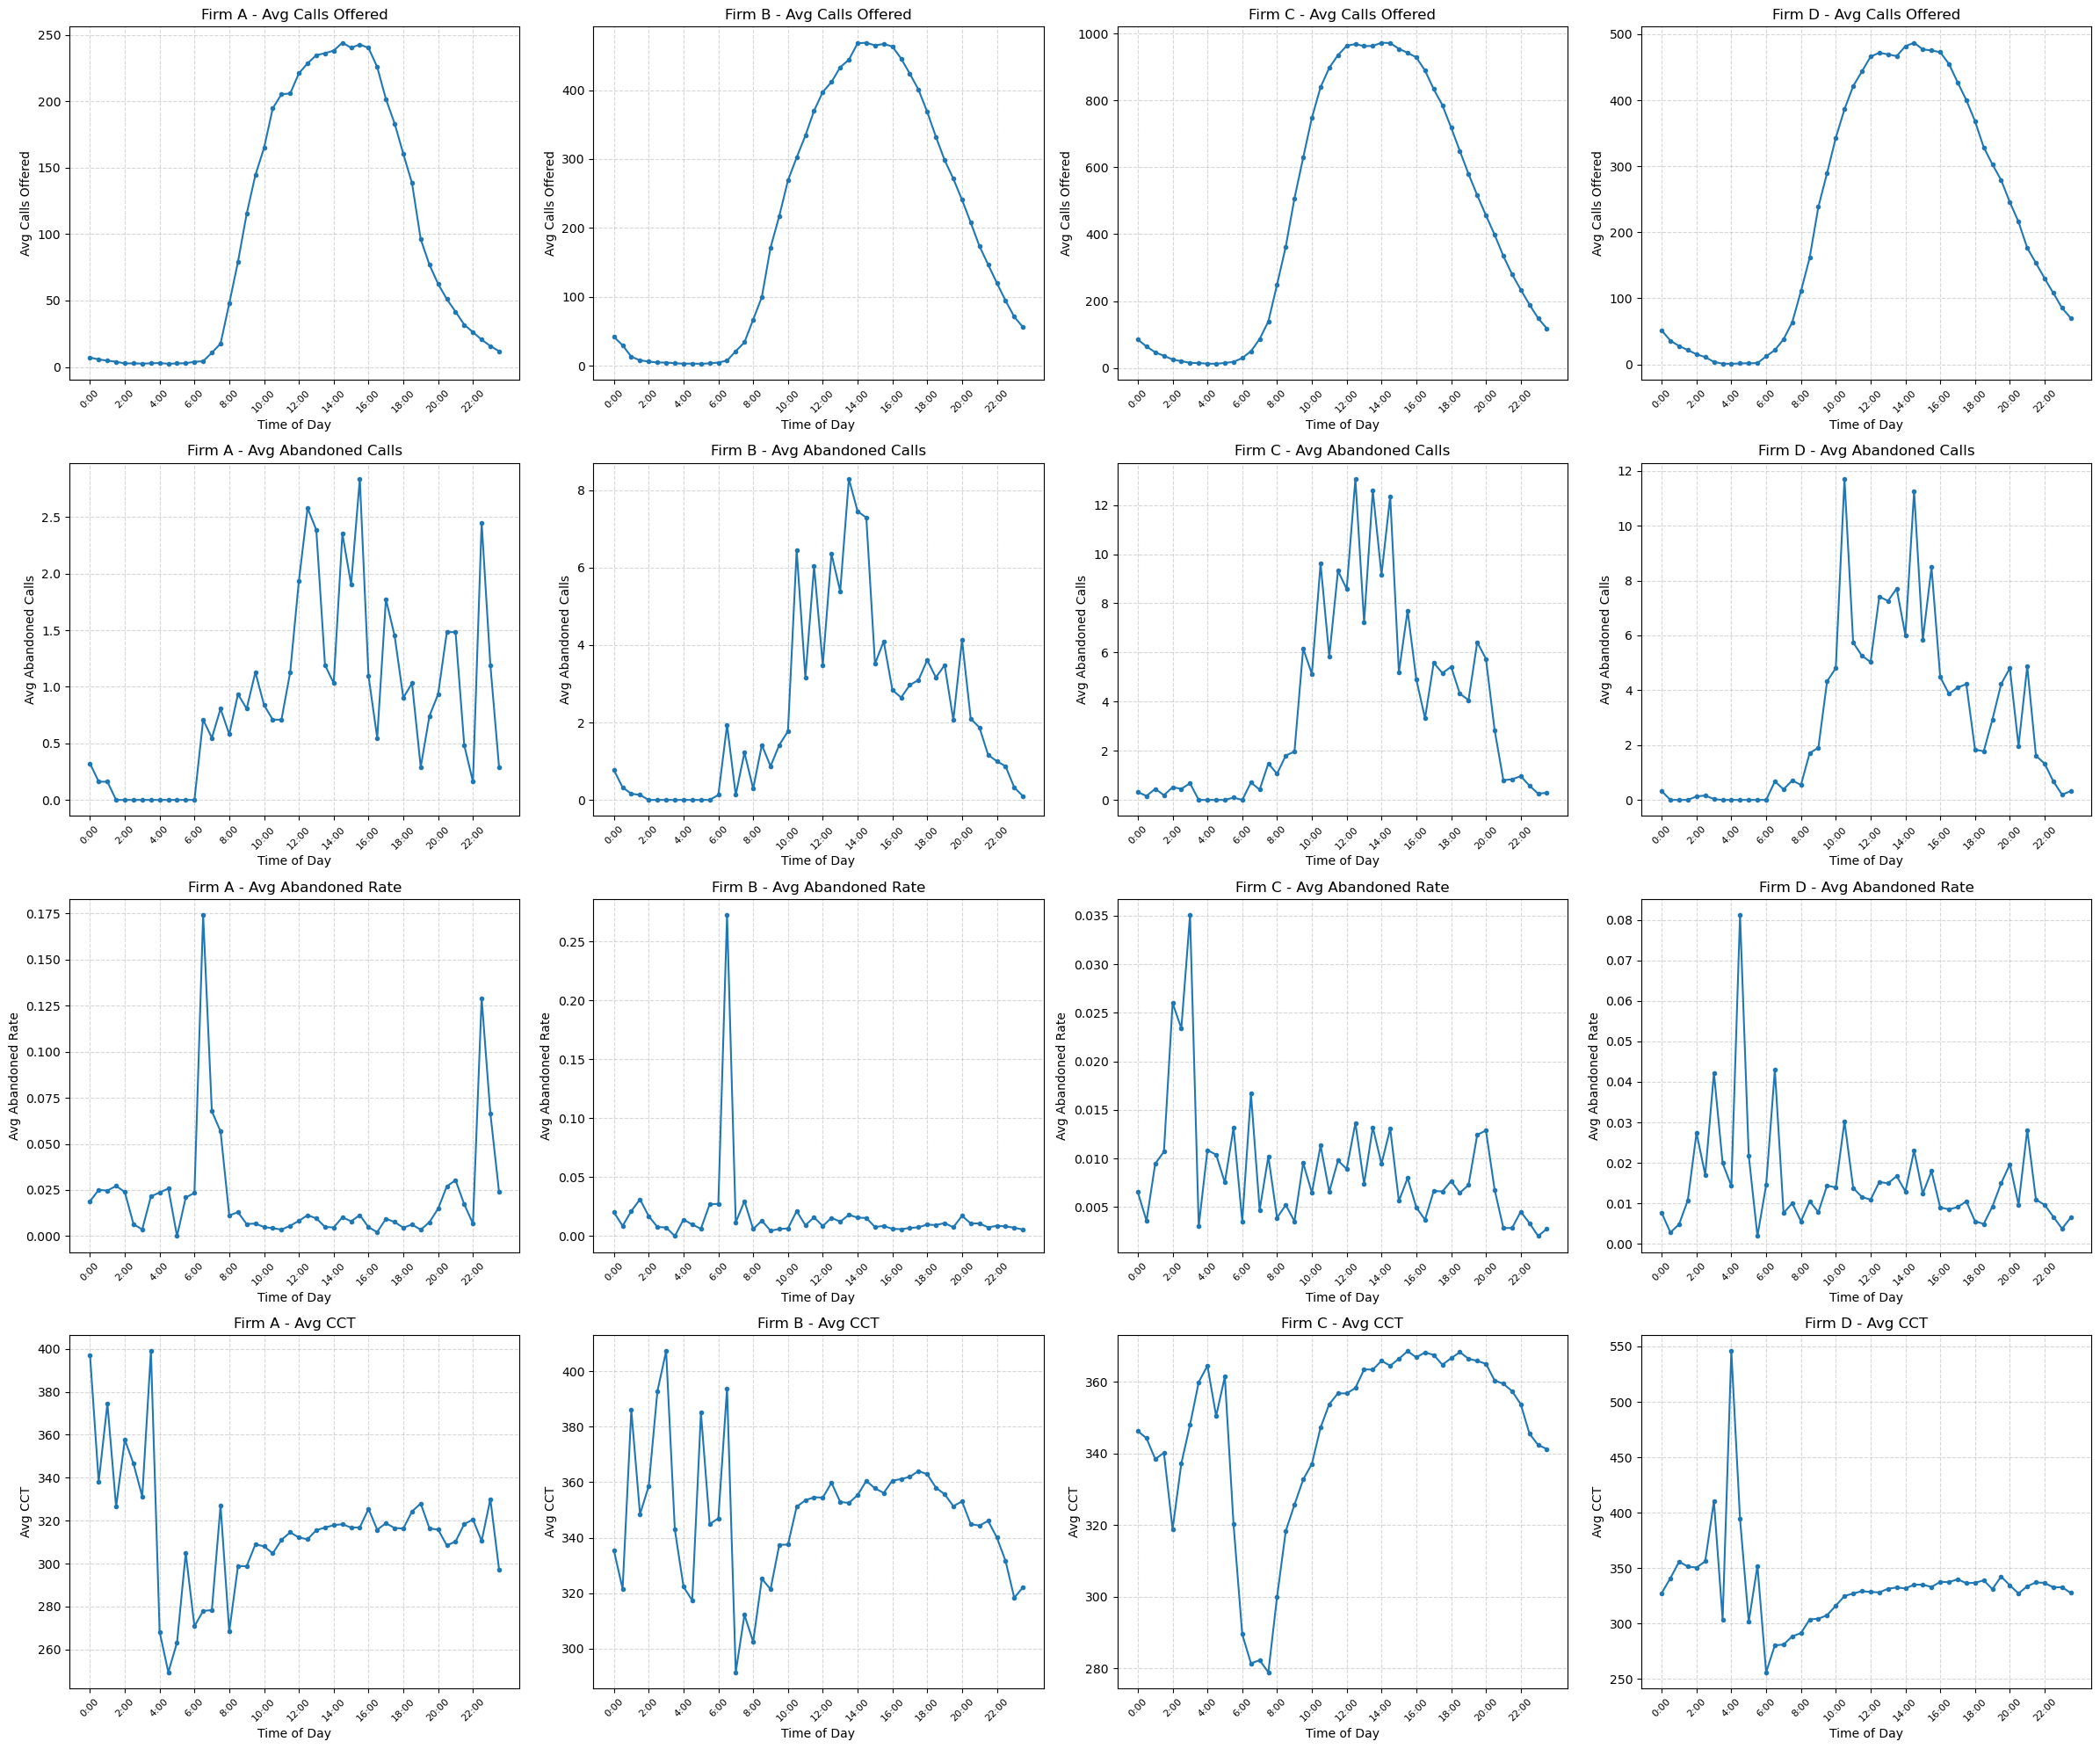

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the forecasted data
df_interval = pd.read_csv('./August_2026_v05.csv')

# 2. Force chronological sorting for the 'Interval' strings
# (Grabbing the unique intervals in the order they appear on Day 1)
ordered_intervals = df_interval['Interval'].unique()
df_interval['Interval'] = pd.Categorical(df_interval['Interval'], categories=ordered_intervals, ordered=True)

# 3. Setup our grid parameters
firms = ['A', 'B', 'C', 'D']
metrics = {
    'Calls_Offered': 'Calls Offered',
    'Abandoned_Calls': 'Abandoned Calls',
    'Abandoned_Rate': 'Abandoned Rate',
    'CCT': 'CCT'
}

# Create a 4x4 grid of subplots (Metrics as rows, Firms as columns)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 20))

# 4. Generate the plots
for i, (base_metric, title) in enumerate(metrics.items()):
    for j, firm in enumerate(firms):
        ax = axes[i, j]
        col_name = f"{base_metric}_{firm}"
        
        # Calculate the average for this specific interval across the month
        interval_avg = df_interval.groupby('Interval')[col_name].mean().reset_index()
        
        # Plot the data
        ax.plot(interval_avg['Interval'], interval_avg[col_name], marker='o', linewidth=1.5, markersize=3, color='#1f77b4')
        
        # Formatting
        ax.set_title(f'Firm {firm} - Avg {title}')
        ax.set_xlabel('Time of Day')
        ax.set_ylabel(f'Avg {title}')
        
        # Rotate labels and step the ticks so they don't overlap (show every 4th interval / every 2 hours)
        ax.set_xticks(ax.get_xticks()[::4])
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        # Add a subtle grid for easier reading
        ax.grid(True, linestyle='--', alpha=0.5)

# 5. Clean layout and display
plt.tight_layout()
plt.show()

/tmp/ipykernel_498785/482644267.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_avg = df_may.groupby('Interval_Clean')[col_name].mean().reset_index()
/tmp/ipykernel_498785/482644267.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_avg = df_may.groupby('Interval_Clean')[col_name].mean().reset_index()
/tmp/ipykernel_498785/482644267.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_av

ValueError: Categorical categories cannot be null

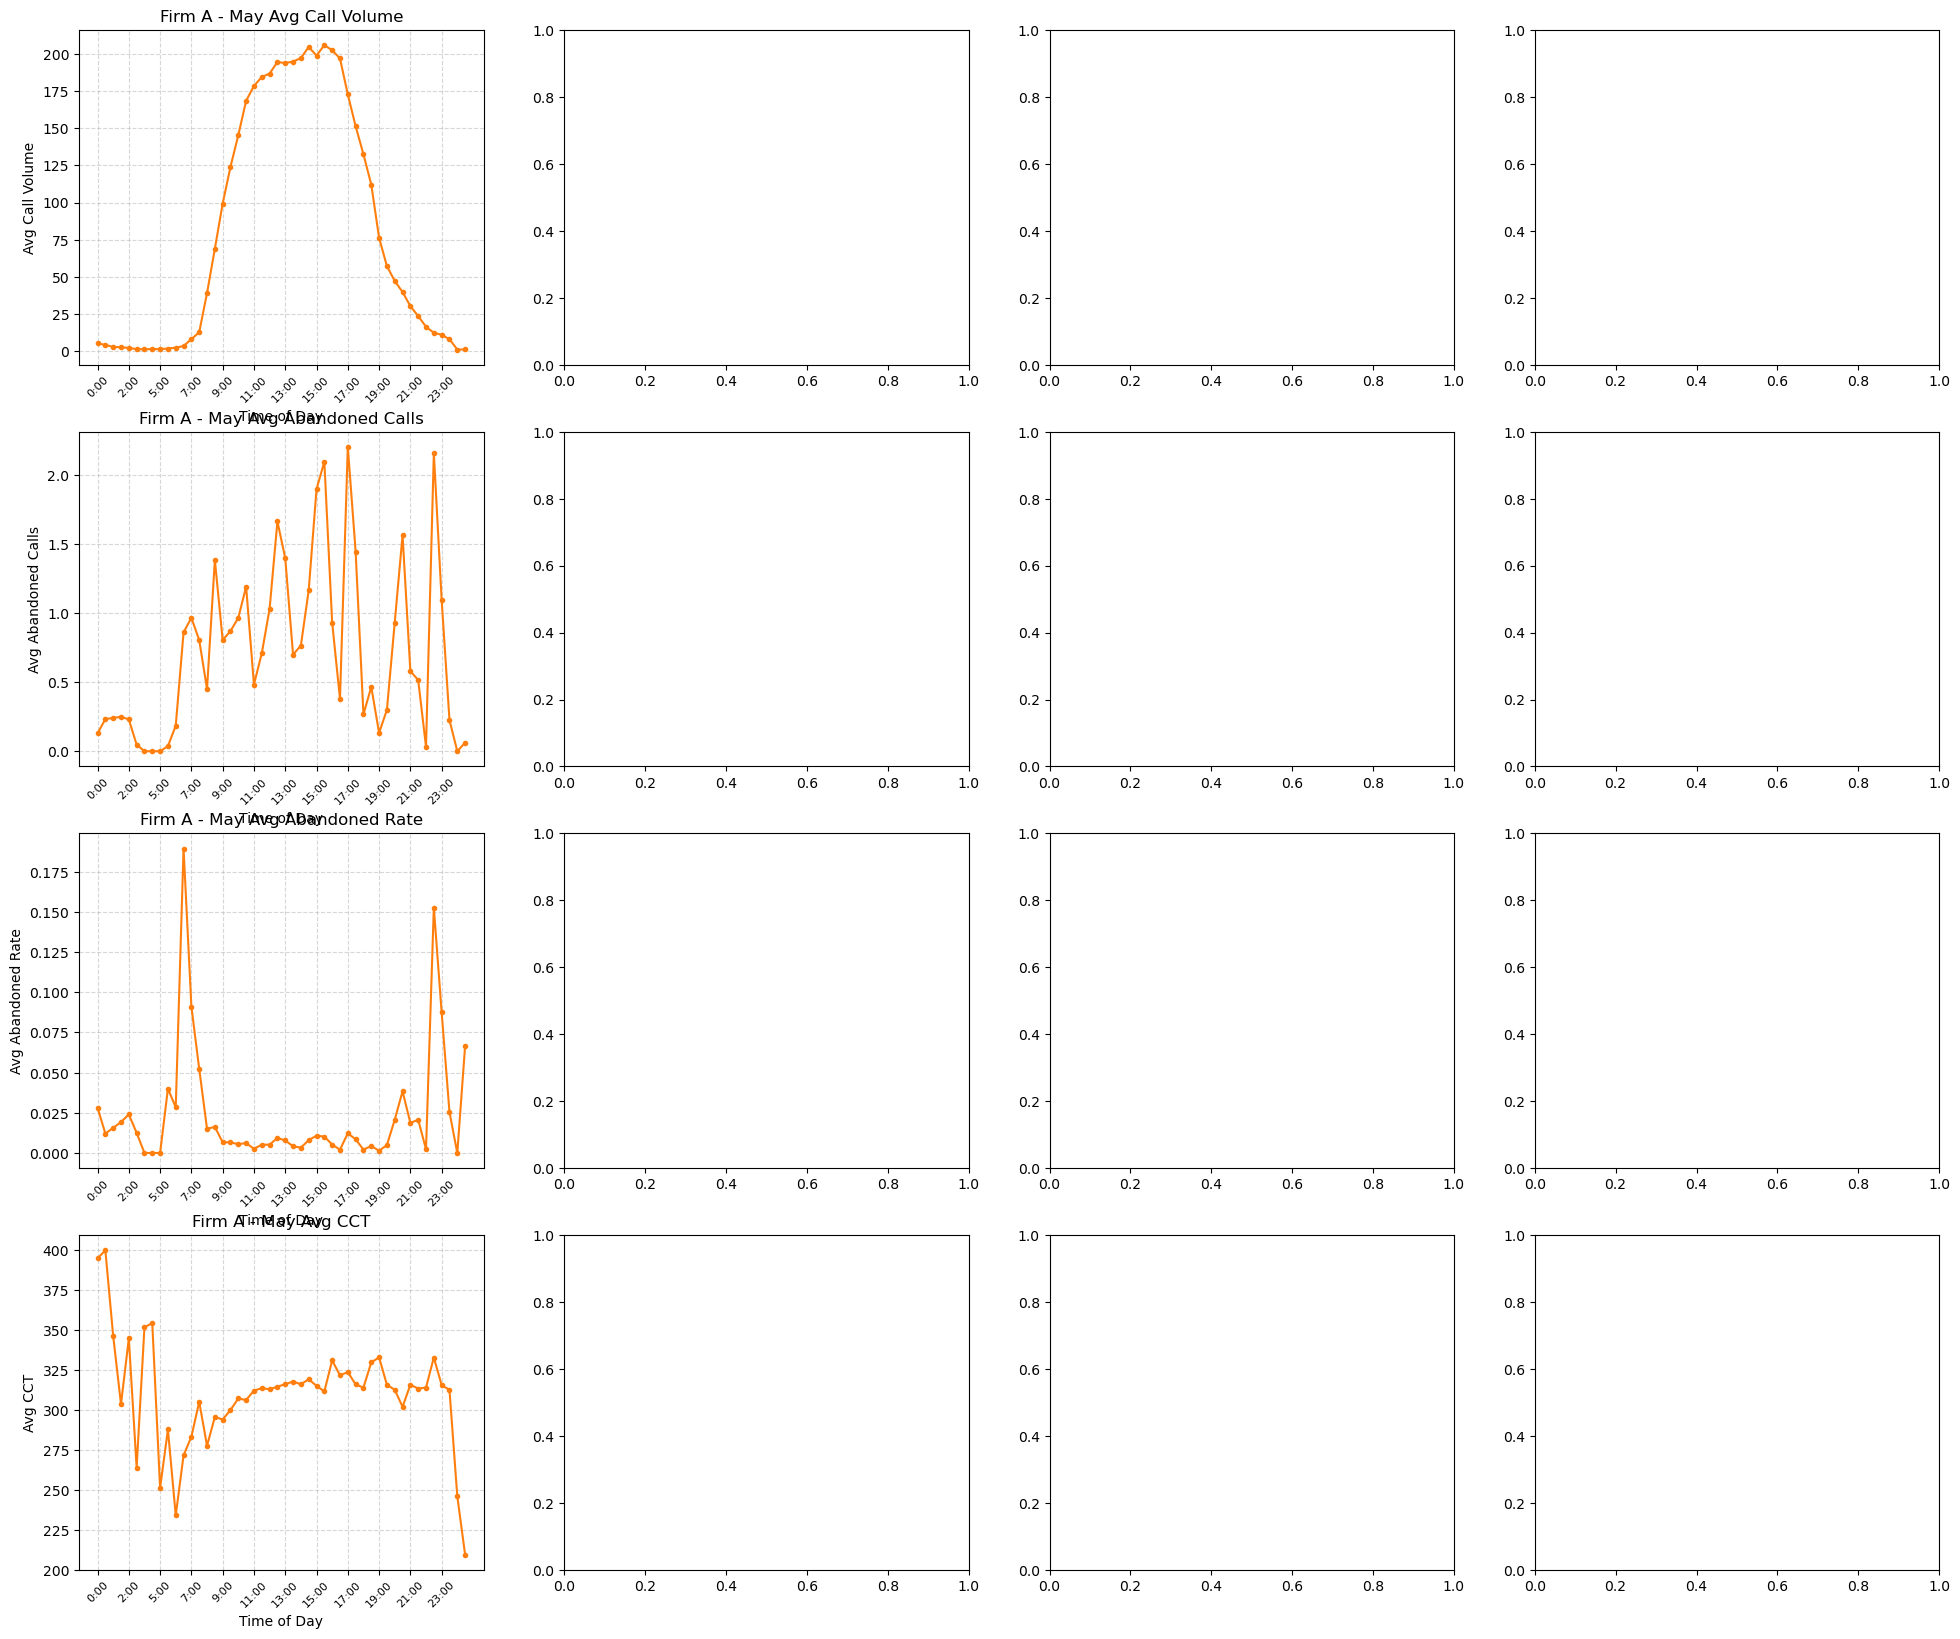

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Setup our grid parameters
firms = ['A', 'B', 'C', 'D']
metrics = {
    'Call Volume': 'Call Volume',
    'Abandoned Calls': 'Abandoned Calls',
    'Abandoned Rate': 'Abandoned Rate',
    'CCT': 'CCT'
}

# Create a 4x4 grid of subplots (Metrics as rows, Firms as columns)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 20))

# 2. Helper function to format intervals to H:MM for clean X-axis labels
def clean_interval(val):
    if pd.isna(val): return val
    parts = str(val).strip().split(':')
    if len(parts) >= 2:
        return f"{int(parts[0])}:{int(parts[1]):02d}"
    return val

# 3. Process each firm and plot
for j, firm in enumerate(firms):
    file_path = f'./data/{firm} - Interval.csv'
    
    if os.path.exists(file_path):
        # Load the raw historical interval data
        df = pd.read_csv(file_path, encoding='utf-8-sig')
        df.columns = df.columns.str.strip() # Remove any hidden spaces
        
        # Filter exclusively for the month of May
        df_may = df[df['Month'] == 'May'].copy()
        
        # Apply clean interval formatting
        df_may['Interval_Clean'] = df_may['Interval'].apply(clean_interval)
        
        # Force chronological sorting based on the order of intervals found
        ordered_intervals = df_may['Interval_Clean'].unique()
        df_may['Interval_Clean'] = pd.Categorical(df_may['Interval_Clean'], categories=ordered_intervals, ordered=True)
        
        # Loop through metrics to plot rows for this firm
        for i, (col_name, title) in enumerate(metrics.items()):
            ax = axes[i, j]
            
            # Calculate the average for this specific interval across May
            interval_avg = df_may.groupby('Interval_Clean')[col_name].mean().reset_index()
            
            # Plot the data
            ax.plot(interval_avg['Interval_Clean'], interval_avg[col_name], marker='o', linewidth=1.5, markersize=3, color='#ff7f0e')
            
            # Formatting
            ax.set_title(f'Firm {firm} - May Avg {title}')
            ax.set_xlabel('Time of Day')
            ax.set_ylabel(f'Avg {title}')
            
            # Rotate labels and step the ticks (show every 4th interval / every 2 hours)
            ax.set_xticks(ax.get_xticks()[::4])
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.grid(True, linestyle='--', alpha=0.5)
            
    else:
        print(f"⚠️ Could not find {file_path}. Skipping Firm {firm}.")

# 4. Clean layout and display
plt.tight_layout()
plt.show()